In [1]:
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
import seaborn as sns

load_dotenv()
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
name = os.getenv('DB_NAME')
user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')

engine = create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{name}")
df = pd.read_sql_table('vw_size_term', engine, 'sba')

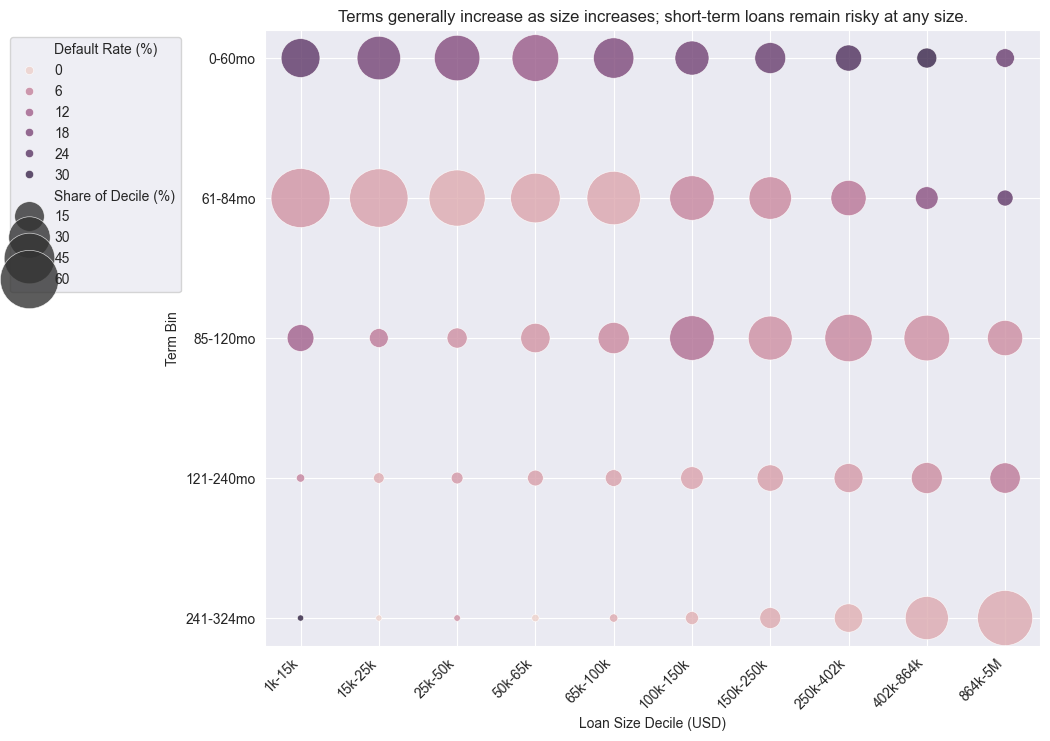

In [2]:
# Colors representing default rate are nonlinear, using gamma = 0.6, to show variation across lower default rates.

sns.set_style('darkgrid')

df = df.rename(columns={'default_rate':'Default Rate (%)', 'term_share_of_decile':'Share of Decile (%)'})

size_min, size_max = 20, 1800

fig, ax = plt.subplots(figsize = (10, 8))

sns.scatterplot(
    data=df,
    x='gross_approval_decile',
    y='term_bin',
    size='Share of Decile (%)',
    hue='Default Rate (%)',
    alpha=0.8,
    sizes=(size_min, size_max),
    hue_norm=PowerNorm(gamma=0.6)
)

plt.xticks(rotation = 45)
plt.legend(loc = 'upper right', bbox_to_anchor = (-0.1, 1))
ax.set_xlabel(xlabel = 'Loan Size Decile (USD)')
ax.set_ylabel(ylabel = 'Term Bin')
ax.set_title('Terms generally increase as size increases; short-term loans remain risky at any size.')
plt.setp(ax.xaxis.get_majorticklabels(), ha = 'right')
plt.show()